Dataset Shape: (600, 15)

Missing Values:
 Name               0
Platform           0
Year_of_Release    0
Genre              0
Publisher          0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
Critic_Score       0
Critic_Count       0
User_Score         0
User_Count         0
Rating             0
dtype: int64

Statistics:
        Year_of_Release    NA_Sales    EU_Sales    JP_Sales  Other_Sales  \
count       600.000000  600.000000  600.000000  600.000000   600.000000   
mean       2016.888333    0.181783    0.126683    0.036600     0.077100   
std           4.884564    0.634638    0.424645    0.143633     0.288575   
min        2008.000000    0.000000    0.000000    0.000000     0.000000   
25%        2013.000000    0.030000    0.020000    0.000000     0.010000   
50%        2017.000000    0.070000    0.050000    0.010000     0.030000   
75%        2021.000000    0.160000    0.110000    0.030000     0.070000   
max        2024

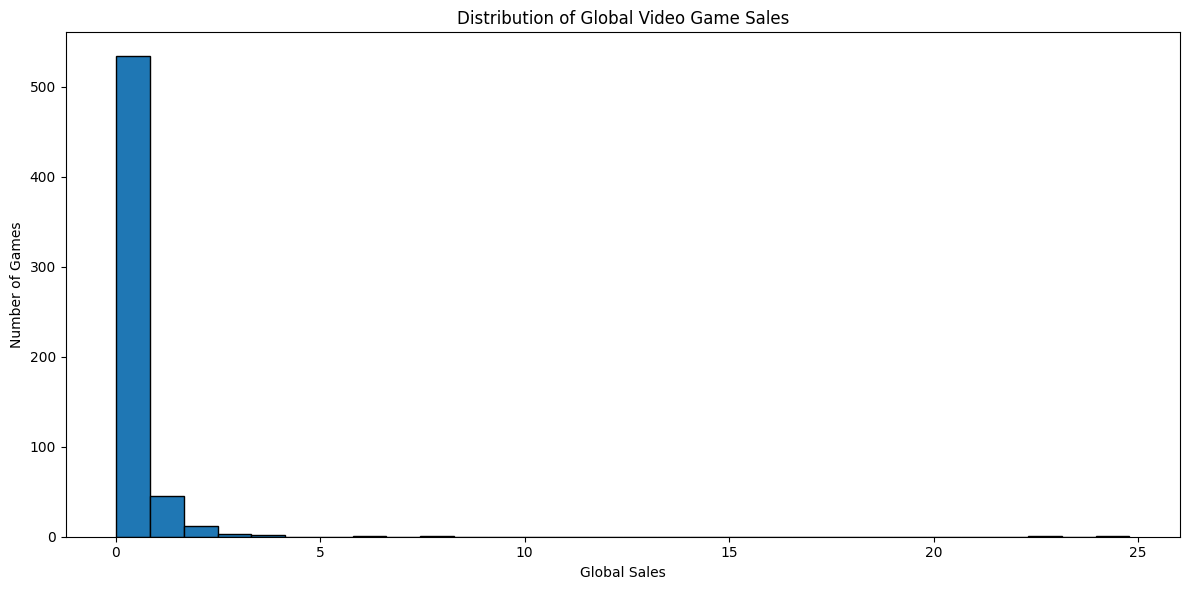

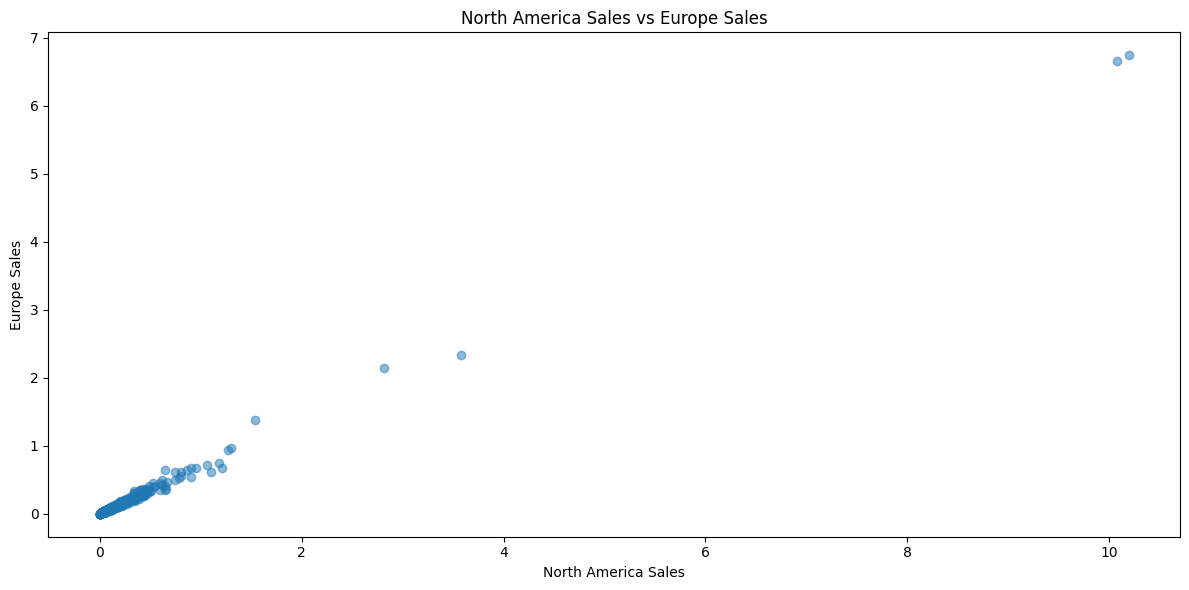

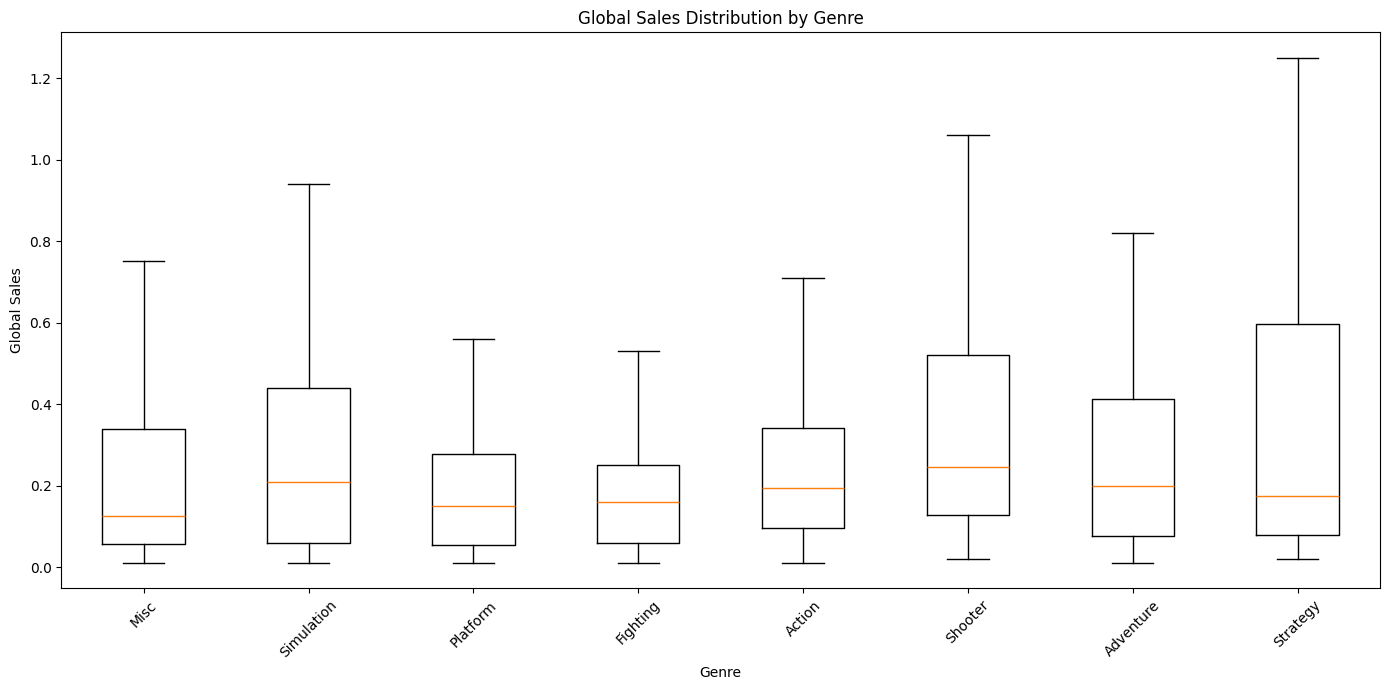

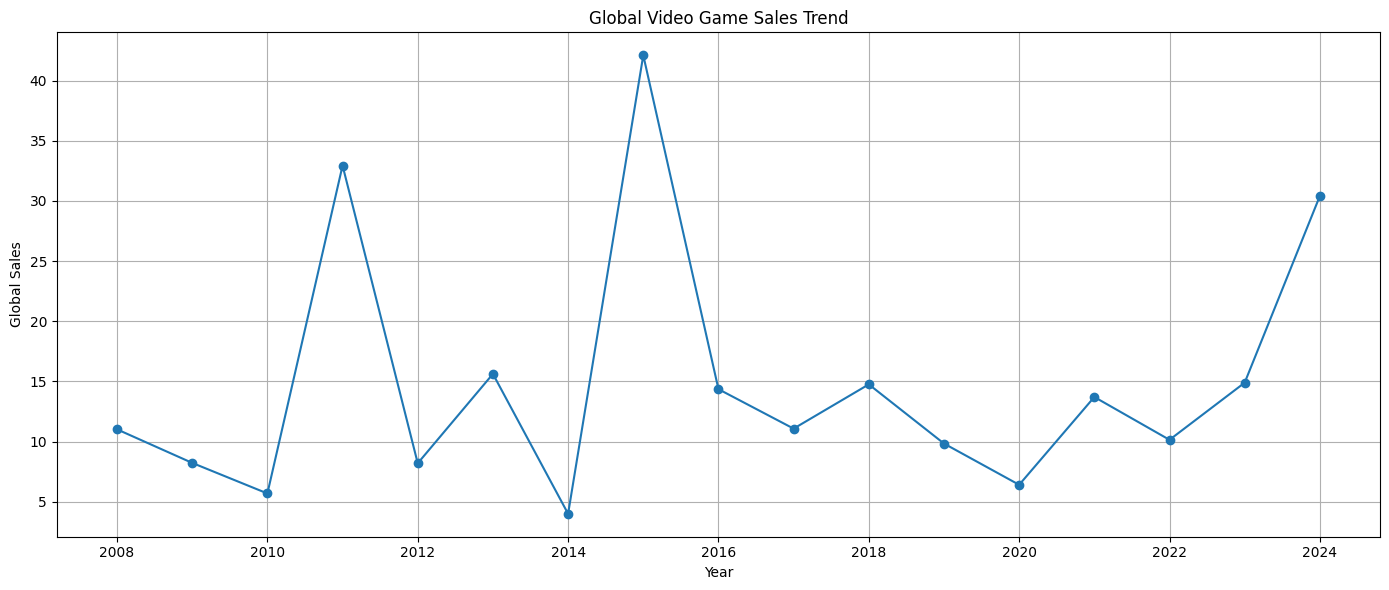

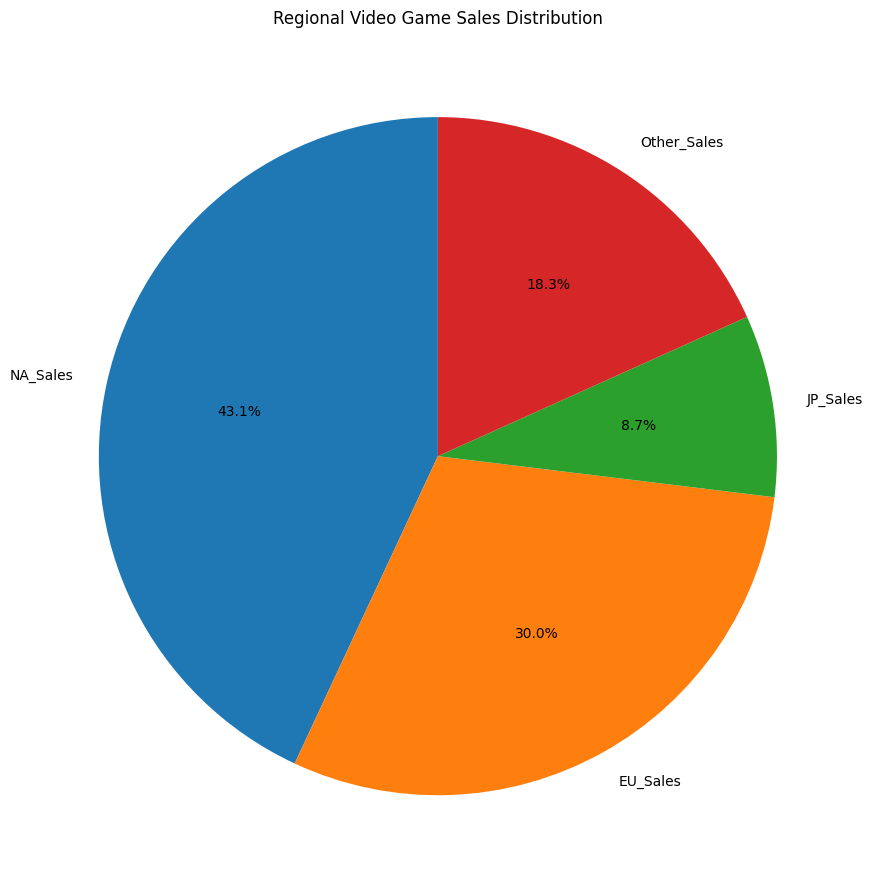

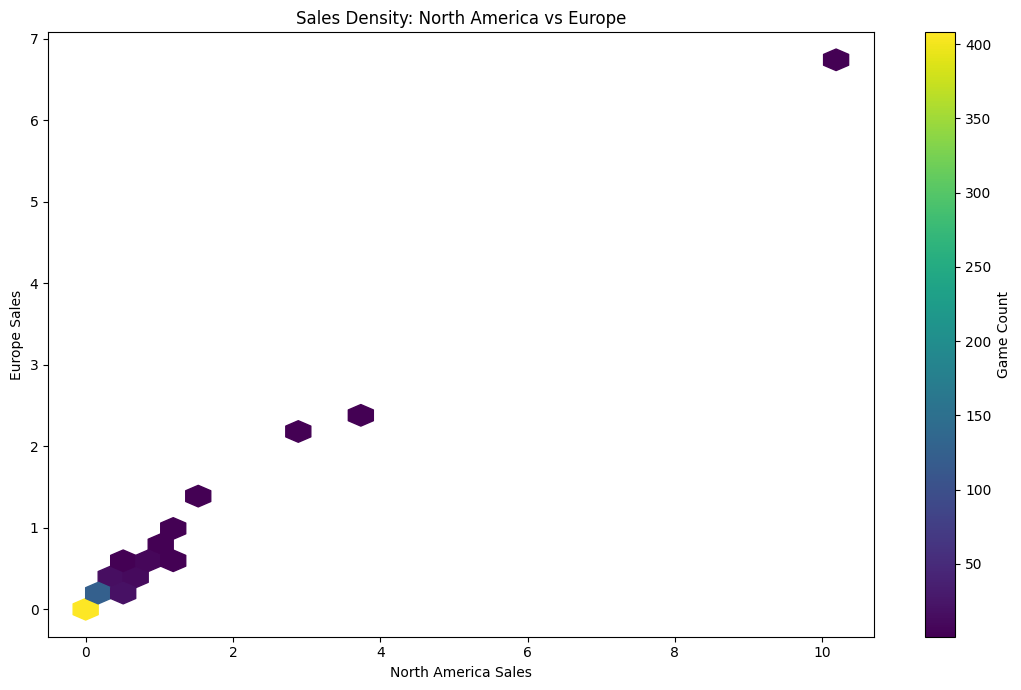

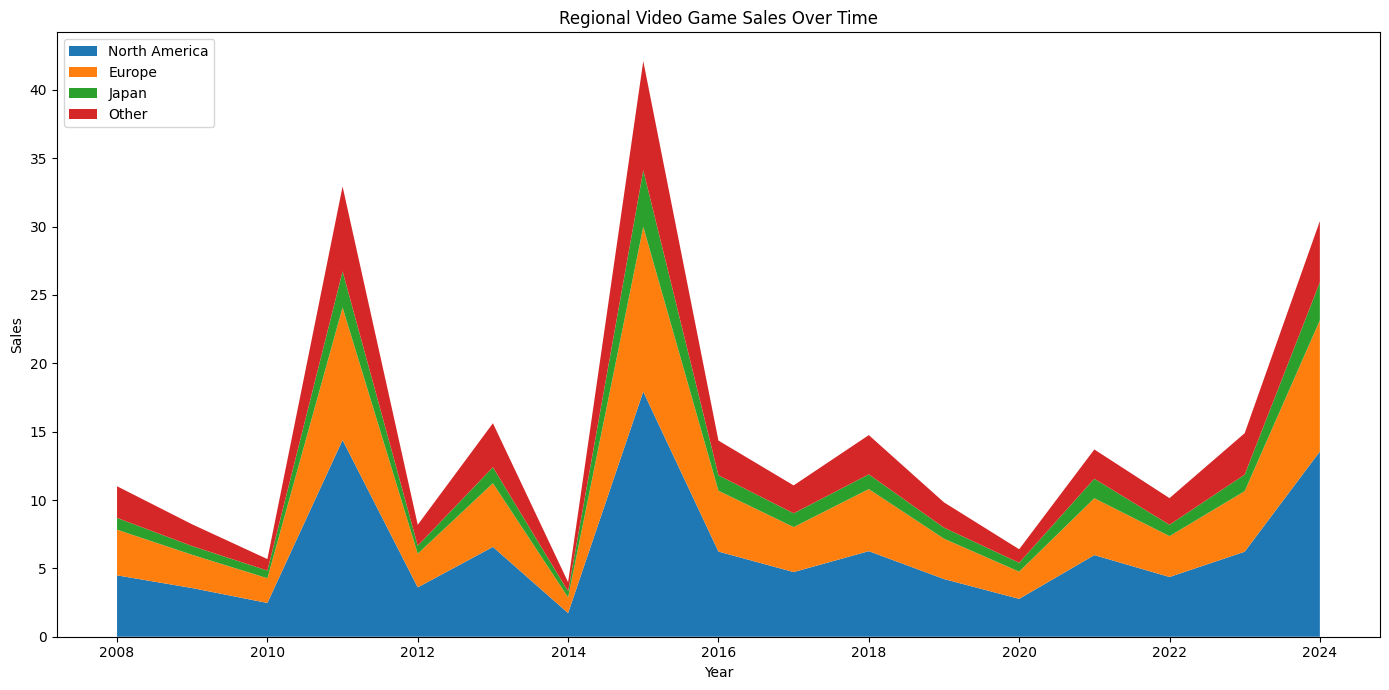


Data Cleaning and Visualization Completed Successfully.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("video_game_sales.csv")

df.columns = df.columns.str.strip()
df = df.drop_duplicates()

numeric_columns = ["Year_of_Release", "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna("Unknown")

df = df.dropna()
df.to_csv("cleaned_video_game_sales.csv", index=False)

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistics:\n", df.describe())

plt.figure(figsize=(12, 6))
plt.hist(df["Global_Sales"], bins=30, edgecolor="black")
plt.title("Distribution of Global Video Game Sales")
plt.xlabel("Global Sales")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(df["NA_Sales"], df["EU_Sales"], alpha=0.5)
plt.title("North America Sales vs Europe Sales")
plt.xlabel("North America Sales")
plt.ylabel("Europe Sales")
plt.tight_layout()
plt.show()

top_genres = df["Genre"].value_counts().head(8).index
genre_data = [df[df["Genre"] == genre]["Global_Sales"] for genre in top_genres]

plt.figure(figsize=(14, 7))
plt.boxplot(genre_data, tick_labels=top_genres, showfliers=False)
plt.title("Global Sales Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Global Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

year_sales = df.groupby("Year_of_Release")["Global_Sales"].sum().sort_index()

plt.figure(figsize=(14, 6))
plt.plot(year_sales.index, year_sales.values, marker="o")
plt.title("Global Video Game Sales Trend")
plt.xlabel("Year")
plt.ylabel("Global Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

region_sales = df[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum()

plt.figure(figsize=(9, 9))
plt.pie(region_sales, labels=region_sales.index, autopct="%1.1f%%", startangle=90)
plt.title("Regional Video Game Sales Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 7))
plt.hexbin(df["NA_Sales"], df["EU_Sales"], gridsize=30, mincnt=1)
plt.colorbar(label="Game Count")
plt.title("Sales Density: North America vs Europe")
plt.xlabel("North America Sales")
plt.ylabel("Europe Sales")
plt.tight_layout()
plt.show()

regional_year_sales = df.groupby("Year_of_Release")[
    ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
].sum().sort_index()

plt.figure(figsize=(14, 7))
plt.stackplot(
    regional_year_sales.index,
    regional_year_sales["NA_Sales"],
    regional_year_sales["EU_Sales"],
    regional_year_sales["JP_Sales"],
    regional_year_sales["Other_Sales"],
    labels=["North America", "Europe", "Japan", "Other"]
)
plt.title("Regional Video Game Sales Over Time")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("\nData Cleaning and Visualization Completed Successfully.")